# FTW Spain — Mask R-CNN Training and Validation

Training and validation workflow for a 4-band Mask R-CNN baseline on the Fields of the World Spain case study.

In [1]:
!nvidia-smi

Thu Sep 10 14:06:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P0             33W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q geoai-py

In [3]:
import torch
import geoai

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


In [4]:
geoai.download_ftw(
    countries=["spain"],
    output_dir="ftw_data",
)

'ftw_data'

In [5]:
from pathlib import Path

country_dir = Path("ftw_data/spain")

for p in sorted(country_dir.iterdir()):
    print(p.name)

chips_spain.parquet
data_config_spain.json
label_masks
s2_images


In [6]:
!du -sh ftw_data/spain

4.0G	ftw_data/spain


In [7]:
import inspect

print(inspect.signature(geoai.prepare_ftw))
print(geoai.prepare_ftw.__doc__)

(data_dir: str, country: str = 'luxembourg', output_dir: Optional[str] = None, window: str = 'window_a', clip_value: int = 3000, num_test: int = 5, verbose: bool = True) -> Dict[str, Any]
Prepare FTW data for training with geoai's instance segmentation pipeline.

Rescales Sentinel-2 reflectance images from 0-10000 to uint8 (0-255) and
organizes them into ``images/`` and ``labels/`` directories compatible with
``geoai.train_instance_segmentation_model()``.

Args:
    data_dir: Path to the root FTW data directory (containing country
        subdirectories as downloaded by ``download_ftw``).
    country: Country subset to prepare. Defaults to "luxembourg".
    output_dir: Directory to write prepared images and labels. If None,
        defaults to ``"field_boundaries"``.
    window: Which temporal window to use for imagery. The FTW dataset
        provides two Sentinel-2 acquisitions from different dates for
        each chip so that seasonal vegetation differences can help
        delinea

In [8]:
import pandas as pd
from pathlib import Path

root = Path("ftw_data/spain")
meta = pd.read_parquet(root / "chips_spain.parquet")

print(meta.columns.tolist())
print()
print(meta["split"].value_counts())

['aoi_id', 'split', 'geometry']

split
train    2019
test      219
val       202
Name: count, dtype: int64


In [9]:
from pathlib import Path

root = Path("ftw_data/spain")
mask_dir = root / "label_masks"
image_dir = root / "s2_images" / "window_a"

mask_ids = {p.stem for p in mask_dir.glob("*.tif")}
image_ids = {p.stem for p in image_dir.glob("*.tif")}
meta_ids = set(meta["aoi_id"])

print("Metadata :", len(meta_ids))
print("Window A :", len(image_ids))
print("Masks    :", len(mask_ids))

missing_images = meta_ids - image_ids
missing_masks = meta_ids - mask_ids

print("\nMissing Window A:", len(missing_images))
print("Missing masks   :", len(missing_masks))

if missing_masks:
    print("\nMissing mask IDs:")
    print(sorted(missing_masks))

Metadata : 2440
Window A : 2440
Masks    : 0

Missing Window A: 0
Missing masks   : 2440

Missing mask IDs:
['g1_00002_12', 'g1_00002_13', 'g1_00002_14', 'g1_00002_15', 'g1_00002_16', 'g1_00002_17', 'g1_00002_18', 'g1_00003_0', 'g1_00003_1', 'g1_00003_10', 'g1_00003_11', 'g1_00003_12', 'g1_00003_2', 'g1_00003_3', 'g1_00003_4', 'g1_00003_5', 'g1_00003_6', 'g1_00003_7', 'g1_00003_8', 'g1_00003_9', 'g1_00004_10', 'g1_00004_11', 'g1_00004_12', 'g1_00004_13', 'g1_00004_14', 'g1_00004_15', 'g1_00004_16', 'g1_00004_17', 'g1_00004_18', 'g1_00004_9', 'g1_00005_0', 'g1_00005_1', 'g1_00005_2', 'g1_00005_3', 'g1_00005_4', 'g1_00005_5', 'g1_00005_6', 'g1_00005_7', 'g1_00005_8', 'g1_00005_9', 'g1_00006_10', 'g1_00006_11', 'g1_00006_12', 'g1_00006_13', 'g1_00006_14', 'g1_00006_15', 'g1_00006_16', 'g1_00006_17', 'g1_00006_18', 'g1_00007_0', 'g1_00007_1', 'g1_00007_2', 'g1_00007_3', 'g1_00007_4', 'g1_00007_5', 'g1_00007_6', 'g1_00008_11', 'g1_00008_12', 'g1_00008_13', 'g1_00008_14', 'g1_00008_15', 'g1_

In [10]:
from pathlib import Path

root = Path("ftw_data/spain")
mask_dir = root / "label_masks"
image_dir = root / "s2_images" / "window_a"

mask_files = list(mask_dir.rglob("*.tif"))
image_files = list(image_dir.rglob("*.tif"))

print("Window A files:", len(image_files))
print("Mask files    :", len(mask_files))

print("\nExample mask paths:")
for p in mask_files[:5]:
    print(p)

Window A files: 2440
Mask files    : 7296

Example mask paths:
ftw_data/spain/label_masks/semantic_3class/g7_00043_6.tif
ftw_data/spain/label_masks/semantic_3class/g4_00043_1.tif
ftw_data/spain/label_masks/semantic_3class/g3_00019_18.tif
ftw_data/spain/label_masks/semantic_3class/g4_00024_8.tif
ftw_data/spain/label_masks/semantic_3class/g4_00015_11.tif


In [11]:
from pathlib import Path

root = Path("ftw_data/spain")

for p in sorted((root / "label_masks").iterdir()):
    if p.is_dir():
        n = len(list(p.glob("*.tif")))
        print(f"{p.name:20s} {n}")

instance             2432
semantic_2class      2432
semantic_3class      2432


In [12]:
instance_dir = root / "label_masks" / "instance"

instance_files = list(instance_dir.glob("*.tif"))

print("Instance masks:", len(instance_files))
print("\nFirst 5:")
for p in instance_files[:5]:
    print(p)

Instance masks: 2432

First 5:
ftw_data/spain/label_masks/instance/g7_00043_6.tif
ftw_data/spain/label_masks/instance/g4_00043_1.tif
ftw_data/spain/label_masks/instance/g3_00019_18.tif
ftw_data/spain/label_masks/instance/g4_00024_8.tif
ftw_data/spain/label_masks/instance/g4_00015_11.tif


In [13]:
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import rasterio

ROOT = Path("ftw_data/spain")
OUT = Path("prepared_spain")

IMAGE_DIR = ROOT / "s2_images" / "window_a"
MASK_DIR = ROOT / "label_masks" / "instance"

meta = pd.read_parquet(ROOT / "chips_spain.parquet")

# Only image-mask pairs that actually exist
valid_ids = {
    p.stem for p in IMAGE_DIR.glob("*.tif")
} & {
    p.stem for p in MASK_DIR.glob("*.tif")
}

usable = meta[meta["aoi_id"].isin(valid_ids)].copy()

for split in ("train", "val", "test"):
    (OUT / split / "images").mkdir(parents=True, exist_ok=True)
    (OUT / split / "labels").mkdir(parents=True, exist_ok=True)

    subset = usable[usable["split"] == split]

    for aoi_id in subset["aoi_id"]:
        src_image = IMAGE_DIR / f"{aoi_id}.tif"
        src_mask = MASK_DIR / f"{aoi_id}.tif"

        # Match geoai.prepare_ftw(): clip reflectance and scale to uint8
        with rasterio.open(src_image) as src:
            image = src.read()
            profile = src.profile.copy()

        image = np.clip(image, 0, 3000)
        image = (image / 3000 * 255).astype(np.uint8)

        profile.update(dtype="uint8")

        with rasterio.open(
            OUT / split / "images" / f"{aoi_id}.tif",
            "w",
            **profile
        ) as dst:
            dst.write(image)

        shutil.copy2(
            src_mask,
            OUT / split / "labels" / f"{aoi_id}.tif"
        )

print("=== PREPARED FTW SPAIN ===")

for split in ("train", "val", "test"):
    n_images = len(list((OUT / split / "images").glob("*.tif")))
    n_labels = len(list((OUT / split / "labels").glob("*.tif")))
    print(f"{split:5s}: images={n_images}, labels={n_labels}")

=== PREPARED FTW SPAIN ===
train: images=2015, labels=2015
val  : images=201, labels=201
test : images=216, labels=216


In [14]:
import inspect

print(inspect.signature(geoai.train_instance_segmentation_model))
print(geoai.train_instance_segmentation_model.__doc__)

(images_dir: str, labels_dir: str, output_dir: str, input_format: str = 'directory', num_classes: int = 2, num_channels: int = 3, batch_size: int = 4, num_epochs: int = 10, learning_rate: float = 0.005, seed: int = 42, val_split: float = 0.2, visualize: bool = False, device: Optional[torch.device] = None, num_workers: Optional[int] = None, verbose: bool = True, instance_labels: bool = False, multiclass: bool = False, early_stopping_patience: Optional[int] = None, early_stopping_min_delta: float = 0.0, **kwargs: Any) -> torch.nn.modules.module.Module

Train an instance segmentation model using Mask R-CNN.

This is a wrapper function for train_MaskRCNN_model with clearer naming.

Args:
    images_dir (str): Directory containing image GeoTIFF files (for 'directory' format),
        or root directory containing images/ subdirectory (for 'yolo' format),
        or directory containing images (for 'coco' format).
    labels_dir (str): Directory containing label GeoTIFF files (for 'directory'

In [15]:
import inspect
import geoai

print(inspect.signature(geoai.train_MaskRCNN_model))
print(geoai.train_MaskRCNN_model.__doc__)

(images_dir: str, labels_dir: str, output_dir: str, input_format: str = 'directory', num_channels: int = 3, num_classes: int = 2, model: Optional[torch.nn.modules.module.Module] = None, pretrained: bool = True, pretrained_model_path: Optional[str] = None, batch_size: int = 4, num_epochs: int = 10, learning_rate: float = 0.005, seed: int = 42, val_split: float = 0.2, visualize: bool = False, resume_training: bool = False, print_freq: int = 10, device: Optional[torch.device] = None, num_workers: Optional[int] = None, verbose: bool = True, model_name: str = 'maskrcnn_resnet50_fpn', instance_labels: bool = False, multiclass: bool = False, early_stopping_patience: Optional[int] = None, early_stopping_min_delta: float = 0.0) -> torch.nn.modules.module.Module
Train and evaluate Mask R-CNN model for instance segmentation.

This function trains a Mask R-CNN model for instance segmentation using the
provided dataset. It supports loading a pretrained model to either initialize
the backbone or to 

In [16]:
from pathlib import Path
import shutil

src_img = Path("prepared_spain/train/images")
src_lbl = Path("prepared_spain/train/labels")

dst_img = Path("pilot_100/images")
dst_lbl = Path("pilot_100/labels")

dst_img.mkdir(parents=True, exist_ok=True)
dst_lbl.mkdir(parents=True, exist_ok=True)

# Only use image-label pairs
pairs = []

for img in sorted(src_img.glob("*.tif")):
    lbl = src_lbl / img.name
    if lbl.exists():
        pairs.append((img, lbl))

pairs = pairs[:100]

for img, lbl in pairs:
    shutil.copy2(img, dst_img / img.name)
    shutil.copy2(lbl, dst_lbl / lbl.name)

print("Pilot pairs:", len(pairs))
print("Images:", len(list(dst_img.glob("*.tif"))))
print("Labels:", len(list(dst_lbl.glob("*.tif"))))

Pilot pairs: 100
Images: 100
Labels: 100


In [17]:
import time
import geoai

start = time.perf_counter()

geoai.train_instance_segmentation_model(
    images_dir="pilot_100/images",
    labels_dir="pilot_100/labels",
    output_dir="outputs/pilot_100_maskrcnn",
    input_format="directory",
    num_classes=2,
    num_channels=4,
    batch_size=2,
    num_epochs=1,
    learning_rate=0.005,
    seed=42,
    val_split=0.2,
    visualize=False,
    num_workers=0,
    instance_labels=True,
)

elapsed = time.perf_counter() - start

print("\n=== BENCHMARK COMPLETE ===")
print(f"Elapsed: {elapsed / 60:.2f} minutes")


=== BENCHMARK COMPLETE ===
Elapsed: 1.08 minutes


In [18]:
import time
import geoai

start = time.perf_counter()

geoai.train_instance_segmentation_model(
    images_dir="pilot_500/images",
    labels_dir="pilot_500/labels",
    output_dir="outputs/pilot_500_maskrcnn",
    input_format="directory",
    num_classes=2,
    num_channels=4,
    batch_size=2,
    num_epochs=1,
    learning_rate=0.005,
    seed=42,
    val_split=0.2,
    visualize=False,
    num_workers=0,
    instance_labels=True,
)

elapsed = time.perf_counter() - start

print("\n=== BENCHMARK COMPLETE ===")
print(f"Elapsed: {elapsed / 60:.2f} minutes")


=== BENCHMARK COMPLETE ===
Elapsed: 5.14 minutes


In [19]:
from pathlib import Path

n_images = len(list(Path("prepared_spain/train/images").glob("*")))

print(f"Full Spain image count: {n_images}")
print(f"Estimated 1 epoch: {n_images / 500 * 5.14:.1f} min")
print(f"Estimated 3 epochs: {n_images / 500 * 5.14 * 3:.1f} min")

Full Spain image count: 2015
Estimated 1 epoch: 20.7 min
Estimated 3 epochs: 62.1 min


In [20]:
import time
import geoai

start = time.perf_counter()

geoai.train_instance_segmentation_model(
    images_dir="prepared_spain/train/images",
    labels_dir="prepared_spain/train/labels",
    output_dir="outputs/spain_maskrcnn_full_1epoch",
    input_format="directory",
    num_classes=2,
    num_channels=4,
    batch_size=2,
    num_epochs=1,
    learning_rate=0.005,
    seed=42,
    val_split=0.2,
    visualize=False,
    num_workers=0,
    instance_labels=True,
)

elapsed = time.perf_counter() - start

print("\n=== FULL TRAINING COMPLETE ===")
print(f"Elapsed: {elapsed / 60:.2f} minutes")


=== FULL TRAINING COMPLETE ===
Elapsed: 20.56 minutes


In [21]:
from pathlib import Path

out = Path("outputs/spain_maskrcnn_full_1epoch")

print("=== OUTPUT FILES ===")
for p in sorted(out.rglob("*")):
    if p.is_file():
        print(p, f"({p.stat().st_size / 1024**2:.2f} MB)")

=== OUTPUT FILES ===
outputs/spain_maskrcnn_full_1epoch/best_model.pth (168.07 MB)
outputs/spain_maskrcnn_full_1epoch/final_model.pth (168.07 MB)
outputs/spain_maskrcnn_full_1epoch/training_history.pth (0.00 MB)
outputs/spain_maskrcnn_full_1epoch/training_summary.txt (0.00 MB)


In [22]:
from pathlib import Path

summary = Path(
    "outputs/spain_maskrcnn_full_1epoch/training_summary.txt"
)

print(summary.read_text())

Training completed on: 2026-09-10 14:39:01
Total epochs: 1
Best validation IoU: 0.6426
Final validation IoU: 0.6426
Final validation loss: 1.8018



In [23]:
import torch

history = torch.load(
    "outputs/spain_maskrcnn_full_1epoch/training_history.pth",
    map_location="cpu",
    weights_only=False
)

print(type(history))

if isinstance(history, dict):
    print("Keys:", history.keys())
    for key, value in history.items():
        print(f"{key}: {value}")
else:
    print(history)

<class 'dict'>
Keys: dict_keys(['train_loss', 'val_loss', 'val_iou', 'epochs', 'lr'])
train_loss: [1.9525489260363982]
val_loss: [1.8017409107472637]
val_iou: [0.6425754916198086]
epochs: [1]
lr: [0.005]


In [24]:
import time
import geoai

start = time.perf_counter()

geoai.train_instance_segmentation_model(
    images_dir="prepared_spain/train/images",
    labels_dir="prepared_spain/train/labels",
    output_dir="outputs/spain_maskrcnn_full_3epochs",
    input_format="directory",
    num_classes=2,
    num_channels=4,
    batch_size=2,
    num_epochs=3,
    learning_rate=0.005,
    seed=42,
    val_split=0.2,
    visualize=False,
    num_workers=0,
    instance_labels=True,
)

elapsed = time.perf_counter() - start

print("\n=== FULL 3-EPOCH TRAINING COMPLETE ===")
print(f"Elapsed: {elapsed / 60:.2f} minutes")


=== FULL 3-EPOCH TRAINING COMPLETE ===
Elapsed: 56.27 minutes


In [25]:
from pathlib import Path

summary = Path(
    "outputs/spain_maskrcnn_full_3epochs/training_summary.txt"
)

print(summary.read_text())

Training completed on: 2026-09-10 15:38:06
Total epochs: 3
Best validation IoU: 0.6712
Final validation IoU: 0.6712
Final validation loss: 1.7493



In [26]:
import torch

history = torch.load(
    "outputs/spain_maskrcnn_full_3epochs/training_history.pth",
    map_location="cpu",
    weights_only=False
)

for key, value in history.items():
    print(f"{key}: {value}")

train_loss: [1.9578400144524521, 1.766007503702608, 1.7243556978629333]
val_loss: [1.816180923197529, 1.7929569707058444, 1.7461410574983842]
val_iou: [0.620614312166048, 0.6559659222525842, 0.6711691577576796]
epochs: [1, 2, 3]
lr: [0.005, 0.005, 0.005]


In [27]:
from pathlib import Path
import shutil

src = Path("outputs/spain_maskrcnn_full_3epochs")
archive = shutil.make_archive(
    "spain_maskrcnn_3epochs",
    "zip",
    root_dir=src
)

print(f"Created: {archive}")

Created: /content/spain_maskrcnn_3epochs.zip


In [28]:
from google.colab import files

files.download("spain_maskrcnn_3epochs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
from pathlib import Path

root = Path("prepared_spain")

for p in sorted(root.rglob("*")):
    if p.is_dir():
        n_files = len([x for x in p.iterdir() if x.is_file()])
        if n_files:
            print(f"{p}: {n_files} files")

prepared_spain/test/images: 216 files
prepared_spain/test/labels: 216 files
prepared_spain/train/images: 2015 files
prepared_spain/train/labels: 2015 files
prepared_spain/val/images: 201 files
prepared_spain/val/labels: 201 files


In [30]:
from pathlib import Path

img_dir = Path("prepared_spain/val/images")
lbl_dir = Path("prepared_spain/val/labels")

images = sorted(img_dir.glob("*"))
labels = sorted(lbl_dir.glob("*"))

print(f"Images: {len(images)}")
print(f"Labels: {len(labels)}")

print("\n=== FIRST 5 PAIRS ===")
for img, lbl in zip(images[:5], labels[:5]):
    print(f"IMAGE: {img.name}")
    print(f"LABEL: {lbl.name}")
    print()

Images: 201
Labels: 201

=== FIRST 5 PAIRS ===
IMAGE: g1_00003_6.tif
LABEL: g1_00003_6.tif

IMAGE: g1_00003_7.tif
LABEL: g1_00003_7.tif

IMAGE: g1_00003_8.tif
LABEL: g1_00003_8.tif

IMAGE: g1_00019_5.tif
LABEL: g1_00019_5.tif

IMAGE: g1_00019_6.tif
LABEL: g1_00019_6.tif



In [31]:
import inspect
import geoai

print(inspect.signature(geoai.instance_segmentation))

(input_path: str, output_path: str, model_path: str, window_size: int = 512, overlap: int = 256, confidence_threshold: float = 0.5, nms_threshold: float = 0.3, batch_size: int = 4, num_channels: int = 3, num_classes: int = 2, class_names: Optional[List[str]] = None, vectorize: bool = False, vector_path: Optional[str] = None, use_mask_geometry: bool = True, simplify_tolerance: float = 0.0, device: Optional[torch.device] = None, **kwargs: Any) -> Dict[str, Any]


In [32]:
import inspect
import geoai

sig = inspect.signature(geoai.instance_segmentation)

for name, param in sig.parameters.items():
    print(name, "=", param.default)

input_path = <class 'inspect._empty'>
output_path = <class 'inspect._empty'>
model_path = <class 'inspect._empty'>
window_size = 512
overlap = 256
confidence_threshold = 0.5
nms_threshold = 0.3
batch_size = 4
num_channels = 3
num_classes = 2
class_names = None
vectorize = False
vector_path = None
use_mask_geometry = True
simplify_tolerance = 0.0
device = None
kwargs = <class 'inspect._empty'>


In [33]:
from pathlib import Path
import geoai

img = Path("prepared_spain/val/images/g1_00003_6.tif")

model = Path(
    "outputs/spain_maskrcnn_full_3epochs/best_model.pth"
)

pred = Path(
    "outputs/validation_predictions/g1_00003_6_pred.tif"
)

pred.parent.mkdir(parents=True, exist_ok=True)

geoai.instance_segmentation(
    input_path=str(img),
    output_path=str(pred),
    model_path=str(model),
    num_channels=4,
    num_classes=2,
    confidence_threshold=0.5,
    device="cuda",
)

print("Prediction saved:", pred)
print("Exists:", pred.exists())

Prediction saved: outputs/validation_predictions/g1_00003_6_pred.tif
Exists: True


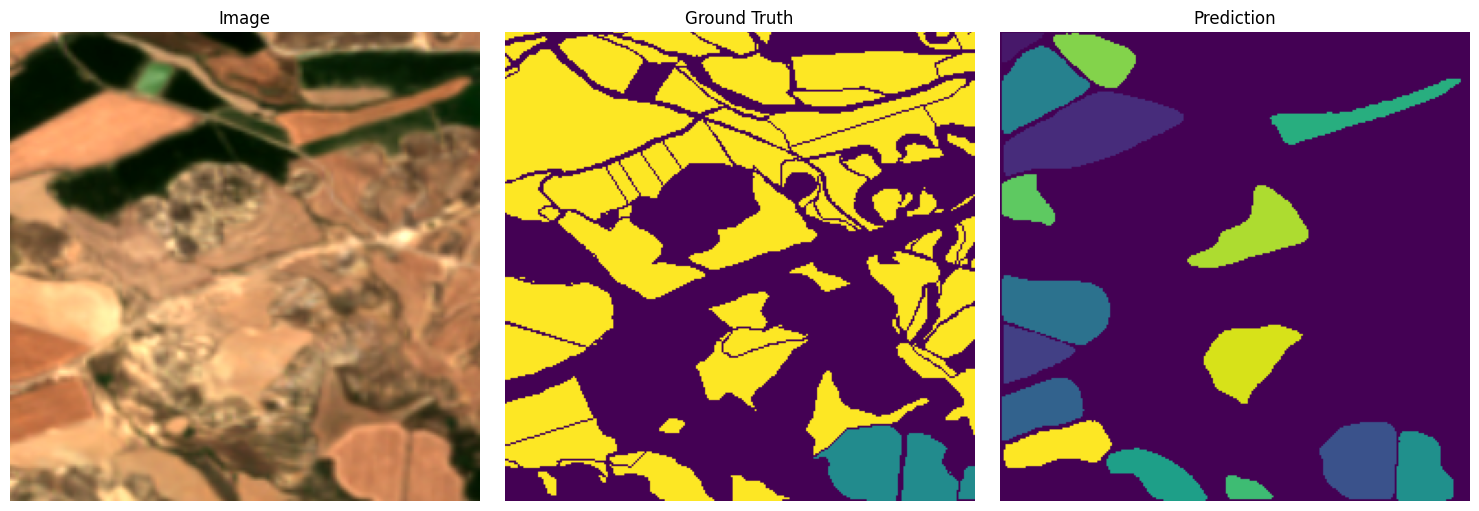

In [34]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

img_path = "prepared_spain/val/images/g1_00003_6.tif"
gt_path = "prepared_spain/val/labels/g1_00003_6.tif"
pred_path = "outputs/validation_predictions/g1_00003_6_pred.tif"

with rasterio.open(img_path) as src:
    image = src.read()

with rasterio.open(gt_path) as src:
    gt = src.read(1)

with rasterio.open(pred_path) as src:
    pred = src.read(1)

# RGB için ilk 3 bandı kullan
rgb = np.moveaxis(image[:3], 0, -1).astype(float)

# Görüntü kontrastını okunabilir hale getir
lo, hi = np.percentile(rgb, (2, 98))
rgb = np.clip((rgb - lo) / (hi - lo), 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(rgb)
axes[0].set_title("Image")

axes[1].imshow(gt)
axes[1].set_title("Ground Truth")

axes[2].imshow(pred)
axes[2].set_title("Prediction")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [35]:
from pathlib import Path
import geoai

img = "prepared_spain/val/images/g1_00003_6.tif"
model = "outputs/spain_maskrcnn_full_3epochs/best_model.pth"

pred03 = Path(
    "outputs/validation_predictions/g1_00003_6_pred_thr03.tif"
)

geoai.instance_segmentation(
    input_path=img,
    output_path=str(pred03),
    model_path=model,
    num_channels=4,
    num_classes=2,
    confidence_threshold=0.3,
    device="cuda",
)

print("0.3 prediction complete:", pred03.exists())

0.3 prediction complete: True


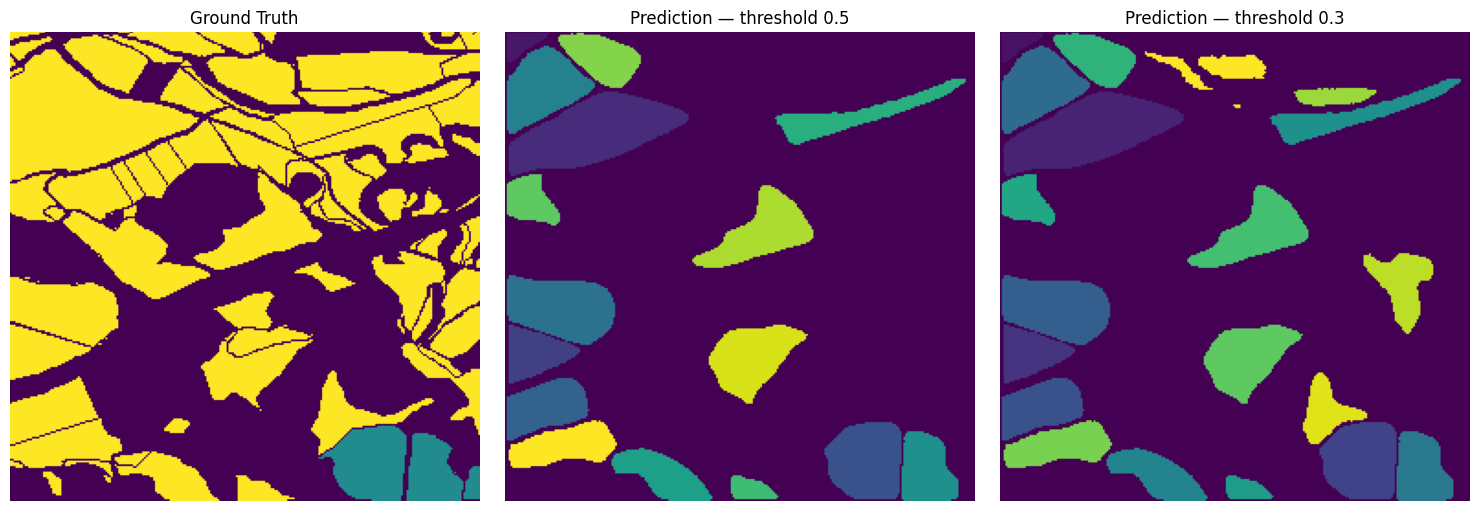

In [36]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

gt_path = "prepared_spain/val/labels/g1_00003_6.tif"
pred05_path = "outputs/validation_predictions/g1_00003_6_pred.tif"
pred03_path = "outputs/validation_predictions/g1_00003_6_pred_thr03.tif"

with rasterio.open(gt_path) as src:
    gt = src.read(1)

with rasterio.open(pred05_path) as src:
    pred05 = src.read(1)

with rasterio.open(pred03_path) as src:
    pred03 = src.read(1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gt)
axes[0].set_title("Ground Truth")

axes[1].imshow(pred05)
axes[1].set_title("Prediction — threshold 0.5")

axes[2].imshow(pred03)
axes[2].set_title("Prediction — threshold 0.3")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [37]:
from pathlib import Path
import geoai

val_dir = Path("prepared_spain/val/images")
model = "outputs/spain_maskrcnn_full_3epochs/best_model.pth"
out_dir = Path("outputs/validation_predictions")
out_dir.mkdir(parents=True, exist_ok=True)

# Validation setinin farklı noktalarından 3 örnek
images = sorted(val_dir.glob("*.tif"))
samples = [
    images[len(images) // 4],
    images[len(images) // 2],
    images[3 * len(images) // 4],
]

for img in samples:
    pred = out_dir / f"{img.stem}_pred_thr03.tif"

    print(f"Running: {img.name}")

    geoai.instance_segmentation(
        input_path=str(img),
        output_path=str(pred),
        model_path=model,
        num_channels=4,
        num_classes=2,
        confidence_threshold=0.3,
        device="cuda",
    )

print("\n=== VALIDATION INFERENCE COMPLETE ===")
for img in samples:
    print(img.name)

Running: g3_00014_10.tif


Running: g4_00015_3.tif


Running: g7_00003_11.tif



=== VALIDATION INFERENCE COMPLETE ===
g3_00014_10.tif
g4_00015_3.tif
g7_00003_11.tif


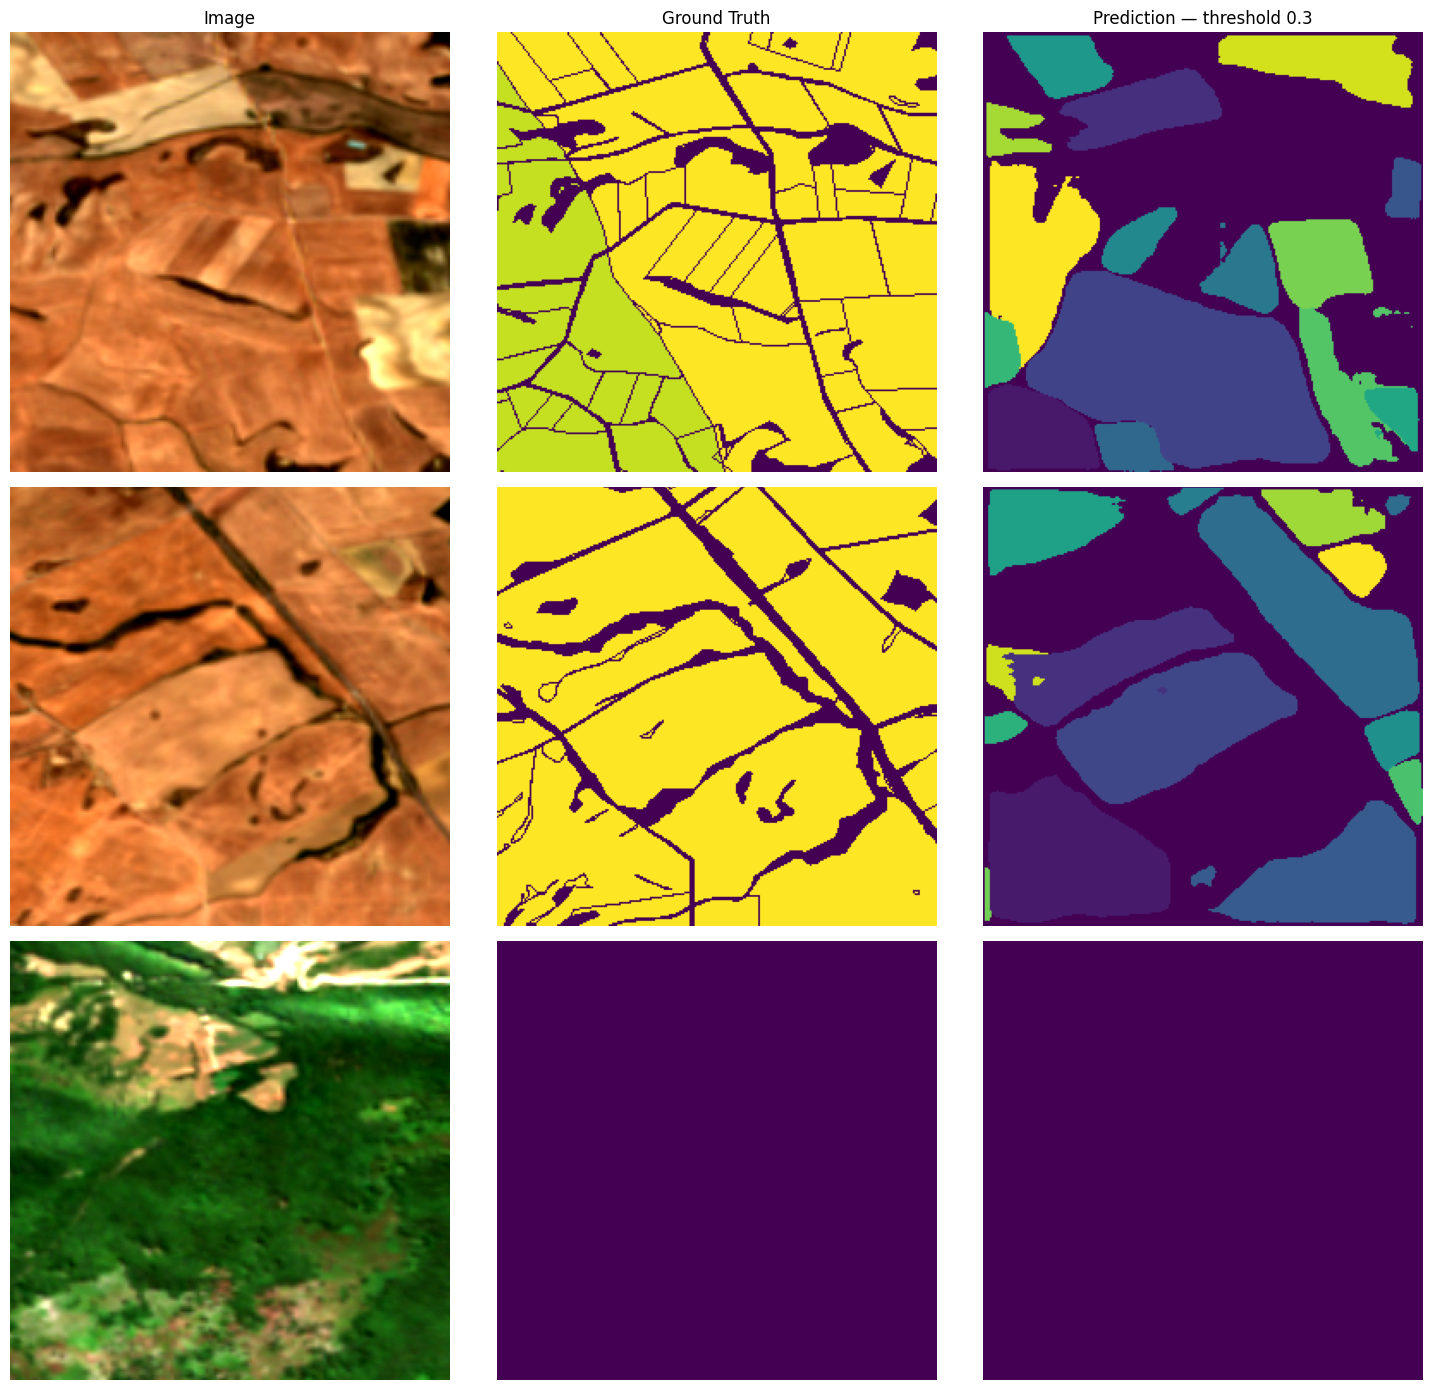

In [38]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

samples = [
    "g3_00014_10.tif",
    "g4_00015_3.tif",
    "g7_00003_11.tif",
]

fig, axes = plt.subplots(len(samples), 3, figsize=(15, 14))

for row, name in enumerate(samples):

    img_path = Path("prepared_spain/val/images") / name
    gt_path = Path("prepared_spain/val/labels") / name
    pred_path = (
        Path("outputs/validation_predictions")
        / f"{Path(name).stem}_pred_thr03.tif"
    )

    with rasterio.open(img_path) as src:
        image = src.read()

    with rasterio.open(gt_path) as src:
        gt = src.read(1)

    with rasterio.open(pred_path) as src:
        pred = src.read(1)

    # RGB visualization
    rgb = np.moveaxis(image[:3], 0, -1).astype(float)
    lo, hi = np.percentile(rgb, (2, 98))
    rgb = np.clip((rgb - lo) / (hi - lo), 0, 1)

    axes[row, 0].imshow(rgb)
    axes[row, 1].imshow(gt)
    axes[row, 2].imshow(pred)

    axes[row, 0].set_ylabel(name, fontsize=10)

for ax in axes.flat:
    ax.axis("off")

axes[0, 0].set_title("Image")
axes[0, 1].set_title("Ground Truth")
axes[0, 2].set_title("Prediction — threshold 0.3")

plt.tight_layout()
plt.show()

In [39]:
from pathlib import Path
import shutil

src = Path("outputs/validation_predictions")

archive = shutil.make_archive(
    "spain_validation_predictions",
    "zip",
    root_dir=src
)

print("Created:", archive)

Created: /content/spain_validation_predictions.zip


In [40]:
from google.colab import files

files.download("spain_validation_predictions.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>